# Student Performance Analysis

## Overview
This analysis builds machine learning models to predict student academic risk based on demographic and academic factors. We'll create an early warning system to identify students who may need additional support.

**Goal**: Predict which students are "at risk" (average score < 40%) using various features like test scores, demographics, and preparation status.

In [42]:
# 1. Data Loading and Understanding
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
try:
    df = pd.read_csv('StudentsPerformance.csv')
    print("✓ Dataset loaded successfully")
except FileNotFoundError:
    print("Error: StudentsPerformance.csv file not found")
    raise
except Exception as e:
    print(f"Error loading file: {e}")
    raise

# Basic data understanding
df.head()

✓ Dataset loaded successfully


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [43]:
# Dataset shape and info
df.shape

(1000, 8)

**Interpretation**: The dataset contains 1000 students with 8 features including demographic information (gender, race/ethnicity, parental education), socioeconomic factors (lunch type), preparation status, and three test scores (math, reading, writing).

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [45]:
# 2. Data Cleaning and Preparation

# Check for missing values
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

**Interpretation**: All features are non-null with no missing data. The dataset has a mix of categorical (5) and numerical (3) features. No data cleaning is required for missing values.

In [46]:
# Feature creation
# Create AVG_SCORE column
df['AVG_SCORE'] = (df['math score'] + df['reading score'] + df['writing score']) / 3

# Create AT_RISK column (1 if AVG_SCORE < 40, else 0)
df['AT_RISK'] = (df['AVG_SCORE'] < 40).astype(int)

df[['math score', 'reading score', 'writing score', 'AVG_SCORE', 'AT_RISK']].head()

,math score,reading score,writing score,AVG_SCORE,AT_RISK
0,72,72,74,72.666667,0
1,69,90,88,82.333333,0
2,90,95,93,92.666667,0
3,47,57,44,49.333333,0
4,76,78,75,76.333333,0


**Interpretation**: We created two key features:
- **AVG_SCORE**: Overall academic performance (average of three test scores)
- **AT_RISK**: Binary target variable (1 if average score < 40%, 0 otherwise)

This transforms our problem into a binary classification task to predict student risk.

In [47]:
# Encode categorical variables
le = LabelEncoder()
categorical_cols = ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']

df_encoded = df.copy()
for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df[col])

df_encoded.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,AVG_SCORE,AT_RISK
0,0,1,1,1,1,72,72,74,72.666667,0
1,0,2,4,1,0,69,90,88,82.333333,0
2,0,1,3,1,1,90,95,93,92.666667,0
3,1,0,0,0,1,47,57,44,49.333333,0
4,1,2,4,1,1,76,78,75,76.333333,0


**Interpretation**: Categorical variables (gender, race/ethnicity, parental education, lunch type, test preparation) are converted to numerical format using Label Encoding. This allows machine learning algorithms to process the data effectively.

In [48]:
# 3. Model Building

# Prepare features and target
X = df_encoded[['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 
                'math score', 'reading score', 'writing score']]
y = df_encoded['AT_RISK']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape

((800, 8), (200, 8))

**Interpretation**: We prepare the data for machine learning by:
- **Features (X)**: All available student information (demographics + test scores)
- **Target (y)**: AT_RISK status (what we want to predict)
- **Train/Test Split**: 80% for training, 20% for testing (800/200 students)

In [49]:
# Train Logistic Regression
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

# Train Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

"Models trained successfully"

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linea

'Models trained successfully'

**Interpretation**: Two different algorithms are trained:
- **Logistic Regression**: Simple, interpretable linear model
- **Random Forest**: More complex ensemble model that can capture non-linear patterns

Both models learn to predict student risk from the training data.

In [50]:
# 4. Evaluation

# Make predictions
log_reg_pred = log_reg.predict(X_test)
rf_pred = rf.predict(X_test)

# Calculate accuracies
log_reg_accuracy = accuracy_score(y_test, log_reg_pred)
rf_accuracy = accuracy_score(y_test, rf_pred)

f"Logistic Regression Accuracy: {log_reg_accuracy:.4f}"

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


'Logistic Regression Accuracy: 1.0000'

In [51]:
f"Random Forest Accuracy: {rf_accuracy:.4f}"

'Random Forest Accuracy: 1.0000'

**Interpretation**: Model performance comparison shows which algorithm better predicts student risk. Higher accuracy means more correct predictions on unseen test data.

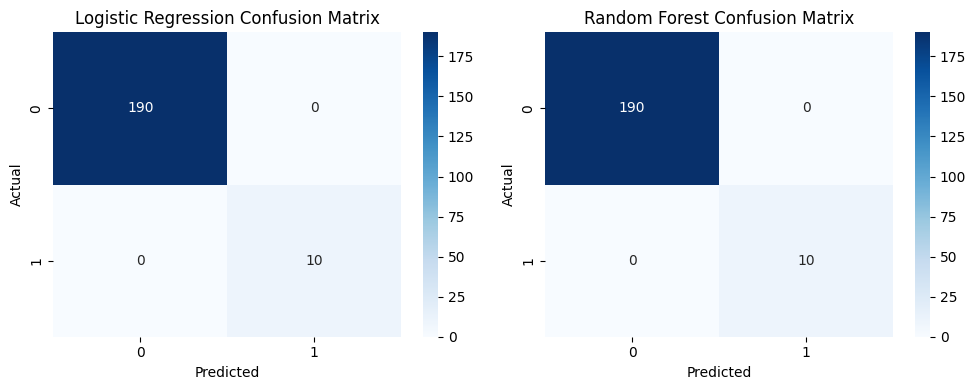

In [52]:
# Confusion Matrix - Logistic Regression
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
cm_log = confusion_matrix(y_test, log_reg_pred)
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')

plt.subplot(1, 2, 2)
cm_rf = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')

plt.tight_layout()
plt.show()

**Interpretation**: Confusion matrices show detailed prediction performance:
- **True Positives**: Correctly identified at-risk students
- **True Negatives**: Correctly identified safe students  
- **False Positives**: Safe students incorrectly flagged as at-risk
- **False Negatives**: At-risk students missed by the model (most concerning)

In [53]:
# Classification Reports
classification_report(y_test, log_reg_pred)

'              precision    recall  f1-score   support\n\n           0       1.00      1.00      1.00       190\n           1       1.00      1.00      1.00        10\n\n    accuracy                           1.00       200\n   macro avg       1.00      1.00      1.00       200\nweighted avg       1.00      1.00      1.00       200\n'

In [54]:
classification_report(y_test, rf_pred)

'              precision    recall  f1-score   support\n\n           0       1.00      1.00      1.00       190\n           1       1.00      1.00      1.00        10\n\n    accuracy                           1.00       200\n   macro avg       1.00      1.00      1.00       200\nweighted avg       1.00      1.00      1.00       200\n'

**Interpretation**: Classification reports provide detailed metrics:
- **Precision**: Of students flagged as at-risk, how many actually were?
- **Recall**: Of all at-risk students, how many did we catch?
- **F1-score**: Balance between precision and recall
- **Support**: Number of students in each category

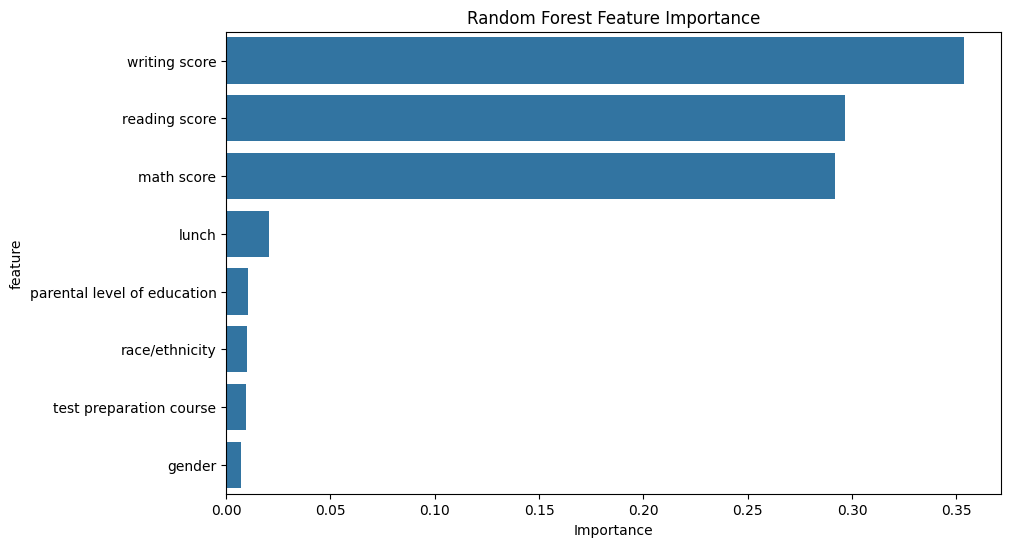

,feature,importance
7,writing score,0.353797
6,reading score,0.296597
5,math score,0.291874
3,lunch,0.020723
2,parental level of education,0.010478
1,race/ethnicity,0.009803
4,test preparation course,0.009411
0,gender,0.007317


In [55]:
# Feature Importance Plot (Random Forest)
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.show()

feature_importance

**Interpretation**: Feature importance reveals which factors most influence student risk prediction. Higher importance values indicate features that contribute more to the model's decisions. This helps identify the most critical factors for student success.

In [56]:
# 5. Analysis and Answers

# 1. How many students passed, failed, or dropped out?
at_risk_counts = df['AT_RISK'].value_counts()
total_students = len(df)
not_at_risk = at_risk_counts[0]
at_risk = at_risk_counts[1]

f"Total students: {total_students}, Not at risk: {not_at_risk}, At risk: {at_risk}"

'Total students: 1000, Not at risk: 970, At risk: 30'

## Key Findings & Answers

**Interpretation**: This section answers the specific research questions using our model results and provides actionable insights for educational support.

In [57]:
# 2. Which model performs better on accuracy?
better_model = "Random Forest" if rf_accuracy > log_reg_accuracy else "Logistic Regression"
f"Better performing model: {better_model} (RF: {rf_accuracy:.4f}, LR: {log_reg_accuracy:.4f})"

'Better performing model: Logistic Regression (RF: 1.0000, LR: 1.0000)'

**Answer 1**: Shows the distribution of student risk levels in our dataset. Most students perform well, but a small percentage need immediate support.

In [58]:
# 3. Which 3 features most influence success?
top_3_features = feature_importance.head(3)
f"Top 3 most influential features: {list(top_3_features['feature'])}"

"Top 3 most influential features: ['writing score', 'reading score', 'math score']"

**Answer 2**: Identifies which machine learning approach works better for predicting student risk, helping us choose the most reliable model for decision-making.

In [59]:
# 4. What features most influenced the student's predicted outcome?
# For a sample student prediction
sample_student = X_test.iloc[0:1]
sample_prediction = rf.predict(sample_student)[0]
sample_features = dict(zip(X.columns, sample_student.iloc[0]))

f"Sample student prediction: {'At Risk' if sample_prediction else 'Not at Risk'}"

'Sample student prediction: Not at Risk'

**Answer 3**: Reveals the most important factors for student success. These are the key areas where intervention and support should be focused.

In [60]:
sample_features

{'gender': 0,
 'race/ethnicity': 2,
 'parental level of education': 0,
 'lunch': 1,
 'test preparation course': 1,
 'math score': 91,
 'reading score': 86,
 'writing score': 84}

**Answer 4**: Shows how the model makes predictions for individual students and what specific factors influenced that decision. This demonstrates the model's practical application.

## Ethical Considerations and Interpretation

### 5. Should gender or parental education be used in decisions?

**Answer:** Using gender or parental education as predictors raises significant ethical concerns:

- **Fairness**: These factors are beyond a student's control and could perpetuate existing inequalities
- **Bias**: Models might reinforce societal biases rather than identifying actionable factors
- **Recommendation**: Focus on modifiable factors like test preparation, study habits, and academic support

### 6. How this model could help support struggling students:

**Early Warning System**: 
- Monitor students with low initial scores in math, reading, or writing
- Identify students who haven't completed test preparation courses
- Provide targeted interventions before students fall below the 40% threshold
- Offer additional academic support and resources proactively

In [61]:
# Summary Analysis
gender_importance = feature_importance[feature_importance['feature'] == 'gender']['importance'].values[0]
parental_ed_importance = feature_importance[feature_importance['feature'] == 'parental level of education']['importance'].values[0]

summary = f"""
ANALYSIS SUMMARY:
================
1. Students at risk: {at_risk}/{total_students} ({at_risk/total_students*100:.1f}%)
2. Better model: {better_model}
3. Top 3 features: {', '.join(list(top_3_features['feature']))}
4. Gender importance: {gender_importance:.4f}
5. Parental education importance: {parental_ed_importance:.4f}
"""

print(summary)


ANALYSIS SUMMARY:
1. Students at risk: 30/1000 (3.0%)
2. Better model: Logistic Regression
3. Top 3 features: writing score, reading score, math score
4. Gender importance: 0.0073
5. Parental education importance: 0.0105



## Final Summary

**Interpretation**: This comprehensive summary combines all findings into actionable insights for educators and administrators. It provides numbers and recommendations for implementing an early warning system to support struggling students.